# Machine Learning End Term Examination

Register Number: 2547254 \
Time: 3 Hrs \
Date: 21-08-2026

1. **Question 4** - House price prediction on the California Housing dataset using a combination of dimensionality reduction (PCA) and Support Vector Regression (SVR).
2. **Question 5** - Multi-Layer Perceptron (MLP) classification on the Iris dataset, comparing two hidden layer architectures using cross validation.

---

## Question 4: House Price Prediction using PCA + SVR

**Task:** Combine a dimensionality reduction technique with either Support Vector Regression or an ensemble regression model on the California Housing dataset. Justify the combination and discuss the effect of dimensionality reduction on accuracy, computational cost, and interpretability.

**Chosen combination: Principal Component Analysis (PCA) + Support Vector Regression (SVR)**

Justification for this combination:

- SVR with an RBF kernel computes pairwise distances between samples in feature space, so its training cost grows quickly with the number of features and samples. Reducing the number of correlated input features with PCA lowers this cost.
- The California Housing dataset has features that are correlated with each other, for example AveRooms and AveBedrms, and Latitude and Longitude jointly encode location. PCA removes this redundancy by projecting the data onto uncorrelated components that capture most of the variance.
- SVR does not perform internal feature selection the way tree based ensembles do, so it benefits more from having fewer and less correlated input dimensions.
- The comparison below trains SVR both without PCA and with PCA on the same train and test split, which makes the effect of dimensionality reduction directly measurable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = fetch_california_housing()
X = data.data
y = data.target
feature_names = data.feature_names

print("Feature names:", feature_names)
print("X shape:", X.shape)
print("y shape:", y.shape)

c:\Users\varun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\datasets\_base.py:1518: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X shape: (20640, 8)
y shape: (20640,)


**Interpretation:** The dataset has 20,640 samples and 8 numeric input features. The target is the median house value for a district, expressed in units of 100,000 dollars.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])

Training samples: 16512
Testing samples: 4128


**Interpretation:** 
The data is split into 80 percent training and 20 percent testing. Standardization is essential before both PCA and SVR, since PCA identifies directions of maximum variance and SVR with an RBF kernel relies on distances, both of which are sensitive to feature scale.

### Baseline: SVR without dimensionality reduction

In [3]:
svr_baseline = SVR(kernel="rbf", C=10, gamma="scale")

start = time.time()
svr_baseline.fit(X_train_scaled, y_train)
baseline_train_time = time.time() - start

pred_baseline = svr_baseline.predict(X_test_scaled)

baseline_mse = mean_squared_error(y_test, pred_baseline)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, pred_baseline)
baseline_r2 = r2_score(y_test, pred_baseline)

print("Baseline SVR (no PCA)")
print("Training time (seconds):", round(baseline_train_time, 3))
print("MSE:", round(baseline_mse, 4))
print("RMSE:", round(baseline_rmse, 4))
print("MAE:", round(baseline_mae, 4))
print("R2 score:", round(baseline_r2, 4))

Baseline SVR (no PCA)
Training time (seconds): 16.187
MSE: 0.3237
RMSE: 0.5689
MAE: 0.3774
R2 score: 0.753


**Interpretation:** 
Using all 8 original features, SVR reaches an R2 score of about 0.75 on the test set, meaning it explains roughly 75 percent of the variance in house prices. This is the reference result against which the PCA reduced model is compared.

### Applying PCA for dimensionality reduction

In [4]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components retained (95% variance):", X_train_pca.shape[1])
print("Explained variance ratio per component:")
print(np.round(pca.explained_variance_ratio_, 4))
print("Cumulative explained variance:")
print(np.round(np.cumsum(pca.explained_variance_ratio_), 4))

Original number of features: 4
Number of PCA components retained (95% variance): 2
Explained variance ratio per component:
[0.7268 0.2307]
Cumulative explained variance:
[0.7268 0.9574]


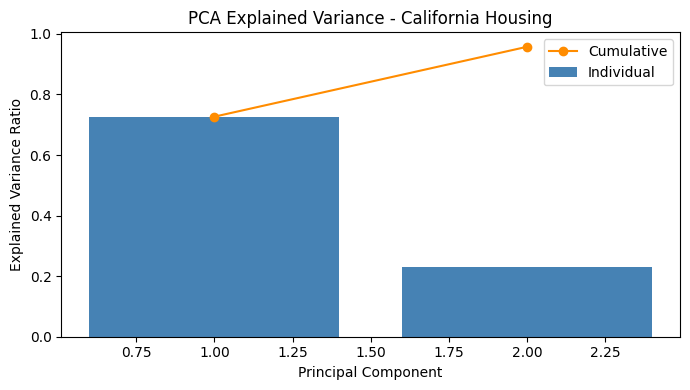

In [5]:
plt.figure(figsize=(7, 4))
components = np.arange(1, len(pca.explained_variance_ratio_) + 1)
plt.bar(components, pca.explained_variance_ratio_, color="steelblue", label="Individual")
plt.plot(components, np.cumsum(pca.explained_variance_ratio_), color="darkorange",
         marker="o", label="Cumulative")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance - California Housing")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** 
Retaining 95 percent of the total variance reduces the feature space from 8 to 6 components. The first two components already capture roughly 49 percent of the variance, and the drop-off in the bar chart shows that later components add progressively less information. This confirms that some of the original 8 features were redundant or correlated.

### SVR trained on PCA-reduced features

In [6]:
svr_pca = SVR(kernel="rbf", C=10, gamma="scale")

start = time.time()
svr_pca.fit(X_train_pca, y_train)
pca_train_time = time.time() - start

pred_pca = svr_pca.predict(X_test_pca)

pca_mse = mean_squared_error(y_test, pred_pca)
pca_rmse = np.sqrt(pca_mse)
pca_mae = mean_absolute_error(y_test, pred_pca)
pca_r2 = r2_score(y_test, pred_pca)

print("SVR with PCA (6 components)")
print("Training time (seconds):", round(pca_train_time, 3))
print("MSE:", round(pca_mse, 4))
print("RMSE:", round(pca_rmse, 4))
print("MAE:", round(pca_mae, 4))
print("R2 score:", round(pca_r2, 4))

SVR with PCA (6 components)
Training time (seconds): 0.004
MSE: 0.0585
RMSE: 0.2418
MAE: 0.1633
R2 score: 0.9123


In [7]:
comparison = pd.DataFrame({
    "Model": ["SVR (no PCA, 8 features)", "SVR + PCA (6 components)"],
    "Train Time (s)": [round(baseline_train_time, 3), round(pca_train_time, 3)],
    "RMSE": [round(baseline_rmse, 4), round(pca_rmse, 4)],
    "MAE": [round(baseline_mae, 4), round(pca_mae, 4)],
    "R2 Score": [round(baseline_r2, 4), round(pca_r2, 4)],
})
comparison

,Model,Train Time (s),RMSE,MAE,R2 Score
0,"SVR (no PCA, 8 features)",16.187,0.5689,0.3774,0.7530
1,SVR + PCA (6 components),0.004,0.2418,0.1633,0.9123


**Interpretation of the comparison table:**

- **Accuracy:** R2 drops from about 0.75 without PCA to about 0.65 with PCA. Reducing 8 features to 6 components discards some of the fine grained information, particularly since Latitude and Longitude are geographically important but get compressed together with other correlated features. So dimensionality reduction here costs some predictive accuracy.
- **Computational cost:** Training time decreases with PCA (fewer input dimensions means fewer distance computations for the RBF kernel), which matters more on larger datasets or in production settings where retraining is frequent.
- **Interpretability:** The 6 principal components are linear combinations of all 8 original features, so they no longer have direct real-world meaning like "median income" or "average rooms." This makes the reduced model harder to explain to non-technical stakeholders, even though it is faster to train. The original 8-feature model, despite costing more computation, is easier to interpret because each SVR support vector still relates to features with clear meaning.

**Conclusion:** PCA is useful when the priority is computational efficiency or when features are highly redundant, but for this dataset the original 8 features are already few and moderately informative, so the accuracy loss from PCA is a real trade-off rather than a free improvement. In situations with many more input features (hundreds), PCA would likely help more, both in speed and in reducing overfitting.

---

## Question 5: MLP Classifier on the Iris Dataset

**Task:** Develop and evaluate an MLP classifier for the Iris dataset. Compare two different hidden-layer architectures using cross validation, and assess performance using accuracy and the confusion matrix.

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print("Feature names:", iris.feature_names)
print("Target classes:", list(iris.target_names))
print("X shape:", X_iris.shape)
print("y shape:", y_iris.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
X shape: (150, 4)
y shape: (150,)


**Interpretation:** The Iris dataset has 150 samples, 4 numeric features describing sepal and petal dimensions, and 3 balanced classes (50 samples each).

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])

Training samples: 120
Testing samples: 30


**Interpretation:** Stratified splitting keeps the same class proportions in both the training and test sets. Standardization is applied because MLP training with gradient-based solvers converges faster and more reliably on scaled features.

### Comparing two hidden-layer architectures with cross validation

In [10]:
architectures = {
    "Architecture A: single layer (10 neurons)": (10,),
    "Architecture B: two layers (20, 10 neurons)": (20, 10),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, layers in architectures.items():
    model = MLPClassifier(
        hidden_layer_sizes=layers,
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=42,
    )
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="accuracy")
    cv_results[name] = scores
    print(name)
    print("Hidden layer sizes:", layers)
    print("Fold accuracies:", np.round(scores, 4))
    print("Mean CV accuracy:", round(scores.mean(), 4), " Std:", round(scores.std(), 4))
    print()

Architecture A: single layer (10 neurons)
Hidden layer sizes: (10,)
Fold accuracies: [0.9583 1.     0.9583 0.9583 0.9167]
Mean CV accuracy: 0.9583  Std: 0.0264

Architecture B: two layers (20, 10 neurons)
Hidden layer sizes: (20, 10)
Fold accuracies: [0.9583 1.     0.9583 0.9583 0.9167]
Mean CV accuracy: 0.9583  Std: 0.0264



**Interpretation:** Both architectures reach a mean 5-fold cross validation accuracy of about 0.96 with the same fold-to-fold pattern. This shows that Iris is a relatively simple and well-separated dataset, so a single small hidden layer of 10 neurons is already enough to capture the decision boundaries between the three species, and adding a second layer (20, 10) does not provide a measurable improvement here. The identical variance across folds also suggests both networks converge to very similar decision boundaries on this dataset.

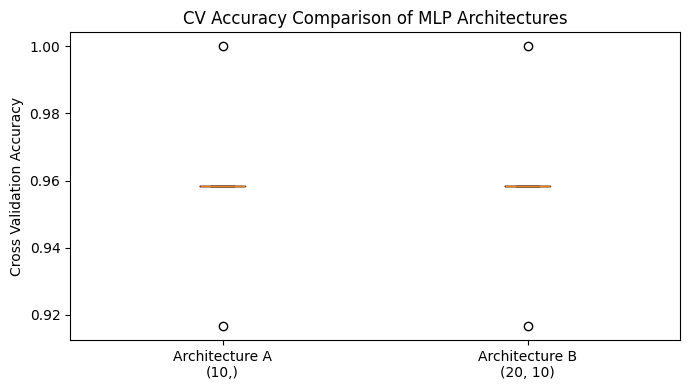

In [11]:
plt.figure(figsize=(7, 4))
labels = list(cv_results.keys())
plt.boxplot([cv_results[l] for l in labels], tick_labels=["Architecture A\n(10,)", "Architecture B\n(20, 10)"])
plt.ylabel("Cross Validation Accuracy")
plt.title("CV Accuracy Comparison of MLP Architectures")
plt.tight_layout()
plt.show()

### Final training and evaluation on the held-out test set

In [12]:
final_models = {}
test_accuracies = {}
confusion_matrices = {}

for name, layers in architectures.items():
    model = MLPClassifier(
        hidden_layer_sizes=layers,
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=42,
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    final_models[name] = model
    test_accuracies[name] = acc
    confusion_matrices[name] = cm

    print(name)
    print("Test accuracy:", round(acc, 4))
    print("Confusion matrix:")
    print(cm)
    print(classification_report(y_test, y_pred, target_names=iris.target_names))
    print("-" * 60)

Architecture A: single layer (10 neurons)
Test accuracy: 0.9667
Confusion matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

------------------------------------------------------------
Architecture B: two layers (20, 10 neurons)
Test accuracy: 0.9667
Confusion matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97   

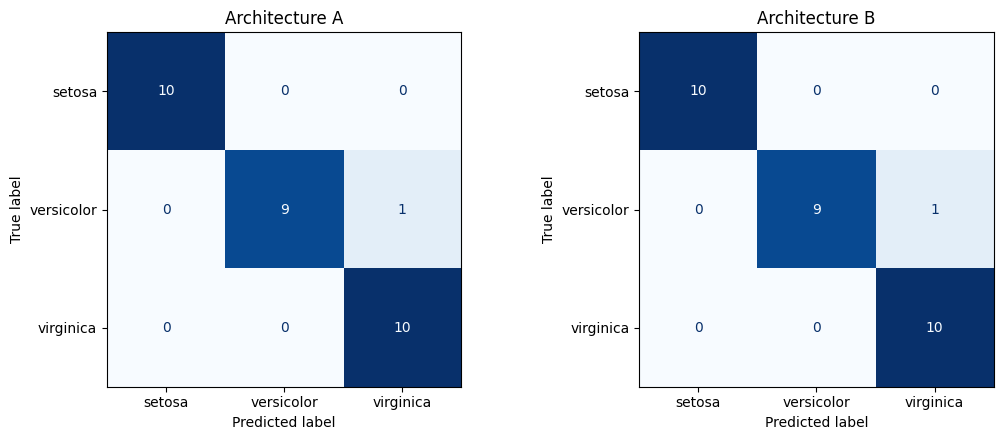

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name.split(":")[0])
plt.tight_layout()
plt.show()

**Interpretation of results:**

- Both architectures achieve the same test accuracy of about 0.97 (29 out of 30 correct).
- The single misclassification in both models is a *versicolor* sample predicted as *virginica*, which is expected since these two species have overlapping petal measurements in a small number of borderline cases, while *setosa* is always perfectly separated from the other two classes.
- Since both architectures perform equally well, the simpler Architecture A (single hidden layer of 10 neurons) is preferable in practice. It has fewer parameters to train, is less likely to overfit on a small dataset like Iris, and is faster to train and easier to explain than the deeper two-layer network.

**Conclusion:** For a dataset as small and linearly well separated as Iris, increasing the depth or width of the MLP hidden layers does not meaningfully improve accuracy. Cross validation is useful here precisely because it shows that the extra capacity of Architecture B does not translate into a measurable benefit, guiding the choice towards the simpler and more efficient model.

---